# Framingham Heart Study - CVD Prediction - Data Exploration & Preprocessing 

This notebook explores the dataset, identifies patterns, and prepares data for modeling.

## 1. Load and Inspect Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Configure display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

# Load the dataset
data_path = Path('..') / 'Framingham_Data' / 'framingham.csv'
df = pd.read_csv(data_path)

print(f'Dataset shape: {df.shape}')
print('First few rows:')
df.head()

Dataset shape: (4240, 16)
First few rows:


,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,1,39,4.0,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,0,46,2.0,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,1,48,1.0,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,0,61,3.0,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,0,46,3.0,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0


In [2]:
print('Dataset Info:')
print(df.info())
print('Basic Statistics:')
df.describe()

Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 4240 entries, 0 to 4239
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   male             4240 non-null   int64  
 1   age              4240 non-null   int64  
 2   education        4135 non-null   float64
 3   currentSmoker    4240 non-null   int64  
 4   cigsPerDay       4211 non-null   float64
 5   BPMeds           4187 non-null   float64
 6   prevalentStroke  4240 non-null   int64  
 7   prevalentHyp     4240 non-null   int64  
 8   diabetes         4240 non-null   int64  
 9   totChol          4190 non-null   float64
 10  sysBP            4240 non-null   float64
 11  diaBP            4240 non-null   float64
 12  BMI              4221 non-null   float64
 13  heartRate        4239 non-null   float64
 14  glucose          3852 non-null   float64
 15  TenYearCHD       4240 non-null   int64  
dtypes: float64(9), int64(7)
memory usage: 530.1 KB
None
Basic

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
count,4240.000000,4240.000000,4135.000000,4240.000000,4211.000000,4187.000000,4240.000000,4240.000000,4240.000000,4190.000000,4240.000000,4240.000000,4221.000000,4239.000000,3852.000000,4240.000000
mean,0.429245,49.580189,1.979444,0.494104,9.005937,0.029615,0.005896,0.310613,0.025708,236.699523,132.354599,82.897759,25.800801,75.878981,81.963655,0.151887
std,0.495027,8.572942,1.019791,0.500024,11.922462,0.169544,0.076569,0.462799,0.158280,44.591284,22.033300,11.910394,4.079840,12.025348,23.954335,0.358953
min,0.000000,32.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,107.000000,83.500000,48.000000,15.540000,44.000000,40.000000,0.000000
25%,0.000000,42.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,206.000000,117.000000,75.000000,23.070000,68.000000,71.000000,0.000000
50%,0.000000,49.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,234.000000,128.000000,82.000000,25.400000,75.000000,78.000000,0.000000
75%,1.000000,56.000000,3.000000,1.000000,20.000000,0.000000,0.000000,1.000000,0.000000,263.000000,144.000000,90.000000,28.040000,83.000000,87.000000,0.000000
max,1.000000,70.000000,4.000000,1.000000,70.000000,1.000000,1.000000,1.000000,1.000000,696.000000,295.000000,142.500000,56.800000,143.000000,394.000000,1.000000


## 2. Check for Missing Values

In [3]:
# Check missing values
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)

missing_df = pd.DataFrame({
    'Column': df.columns,
    'Missing_Count': missing.values,
    'Missing_Percent': missing_pct.values
})

# Show only columns with missing values
print('Missing Values Summary:')
print(missing_df[missing_df['Missing_Count'] > 0].sort_values('Missing_Count', ascending=False))

if (missing == 0).all():
    print('No missing values detected')

Missing Values Summary:
        Column  Missing_Count  Missing_Percent
14     glucose            388             9.15
2    education            105             2.48
5       BPMeds             53             1.25
9      totChol             50             1.18
4   cigsPerDay             29             0.68
12         BMI             19             0.45
13   heartRate              1             0.02


## 3. Target Variable Analysis

Target Variable (TenYearCHD) Distribution:
  0: 3596 (84.81132075471697%)
  1: 644 (15.188679245283017%)


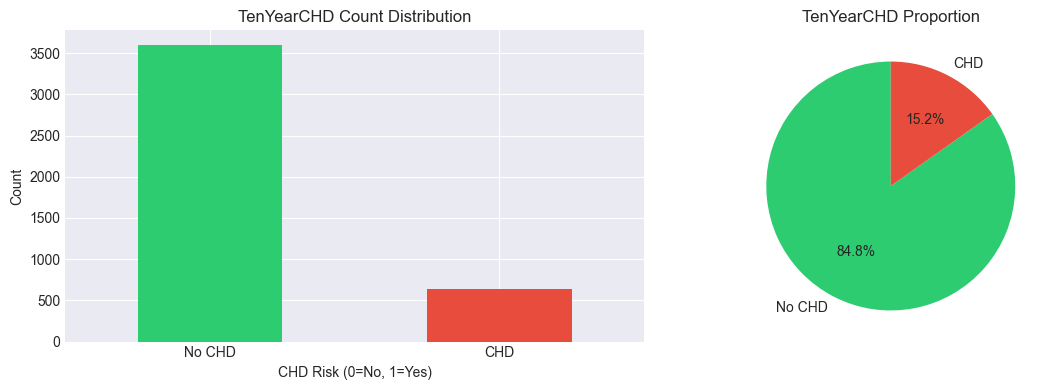

Class Imbalance Ratio: 1:5.583850931677019


In [4]:
# Analyze target variable
print('Target Variable (TenYearCHD) Distribution:')
target_counts = df['TenYearCHD'].value_counts().sort_index()
target_percent = (df['TenYearCHD'].value_counts(normalize=True) * 100)

for idx in target_counts.index:
    print(f'  {idx}: {target_counts[idx]} ({target_percent[idx]}%)')

# Visualize class distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Count plot
target_counts.plot(kind='bar', ax=axes[0], color=['#2ecc71', '#e74c3c'])
axes[0].set_title('TenYearCHD Count Distribution')
axes[0].set_xlabel('CHD Risk (0=No, 1=Yes)')
axes[0].set_ylabel('Count')
axes[0].set_xticklabels(['No CHD', 'CHD'], rotation=0)

# Pie chart
axes[1].pie(target_counts, labels=['No CHD', 'CHD'], autopct='%1.1f%%', 
             colors=['#2ecc71', '#e74c3c'], startangle=90)
axes[1].set_title('TenYearCHD Proportion')

plt.tight_layout()
plt.show()

print(f'Class Imbalance Ratio: 1:{target_counts[0]/target_counts[1]}')

## 4. Feature Analysis

In [5]:
# Identify feature types
binary_features = [col for col in df.columns if df[col].nunique() == 2]
categorical_features = [col for col in df.columns if df[col].nunique() < 10 and col not in binary_features]
continuous_features = [col for col in df.columns if df[col].nunique() >= 10]

print('Feature Classification:')
print(f'Binary features ({len(binary_features)}): {binary_features}')
print(f'Categorical features ({len(categorical_features)}): {categorical_features}')
print(f'Continuous features ({len(continuous_features)}): {continuous_features}')

Feature Classification:
Binary features (7): ['male', 'currentSmoker', 'BPMeds', 'prevalentStroke', 'prevalentHyp', 'diabetes', 'TenYearCHD']
Categorical features (1): ['education']
Continuous features (8): ['age', 'cigsPerDay', 'totChol', 'sysBP', 'diaBP', 'BMI', 'heartRate', 'glucose']


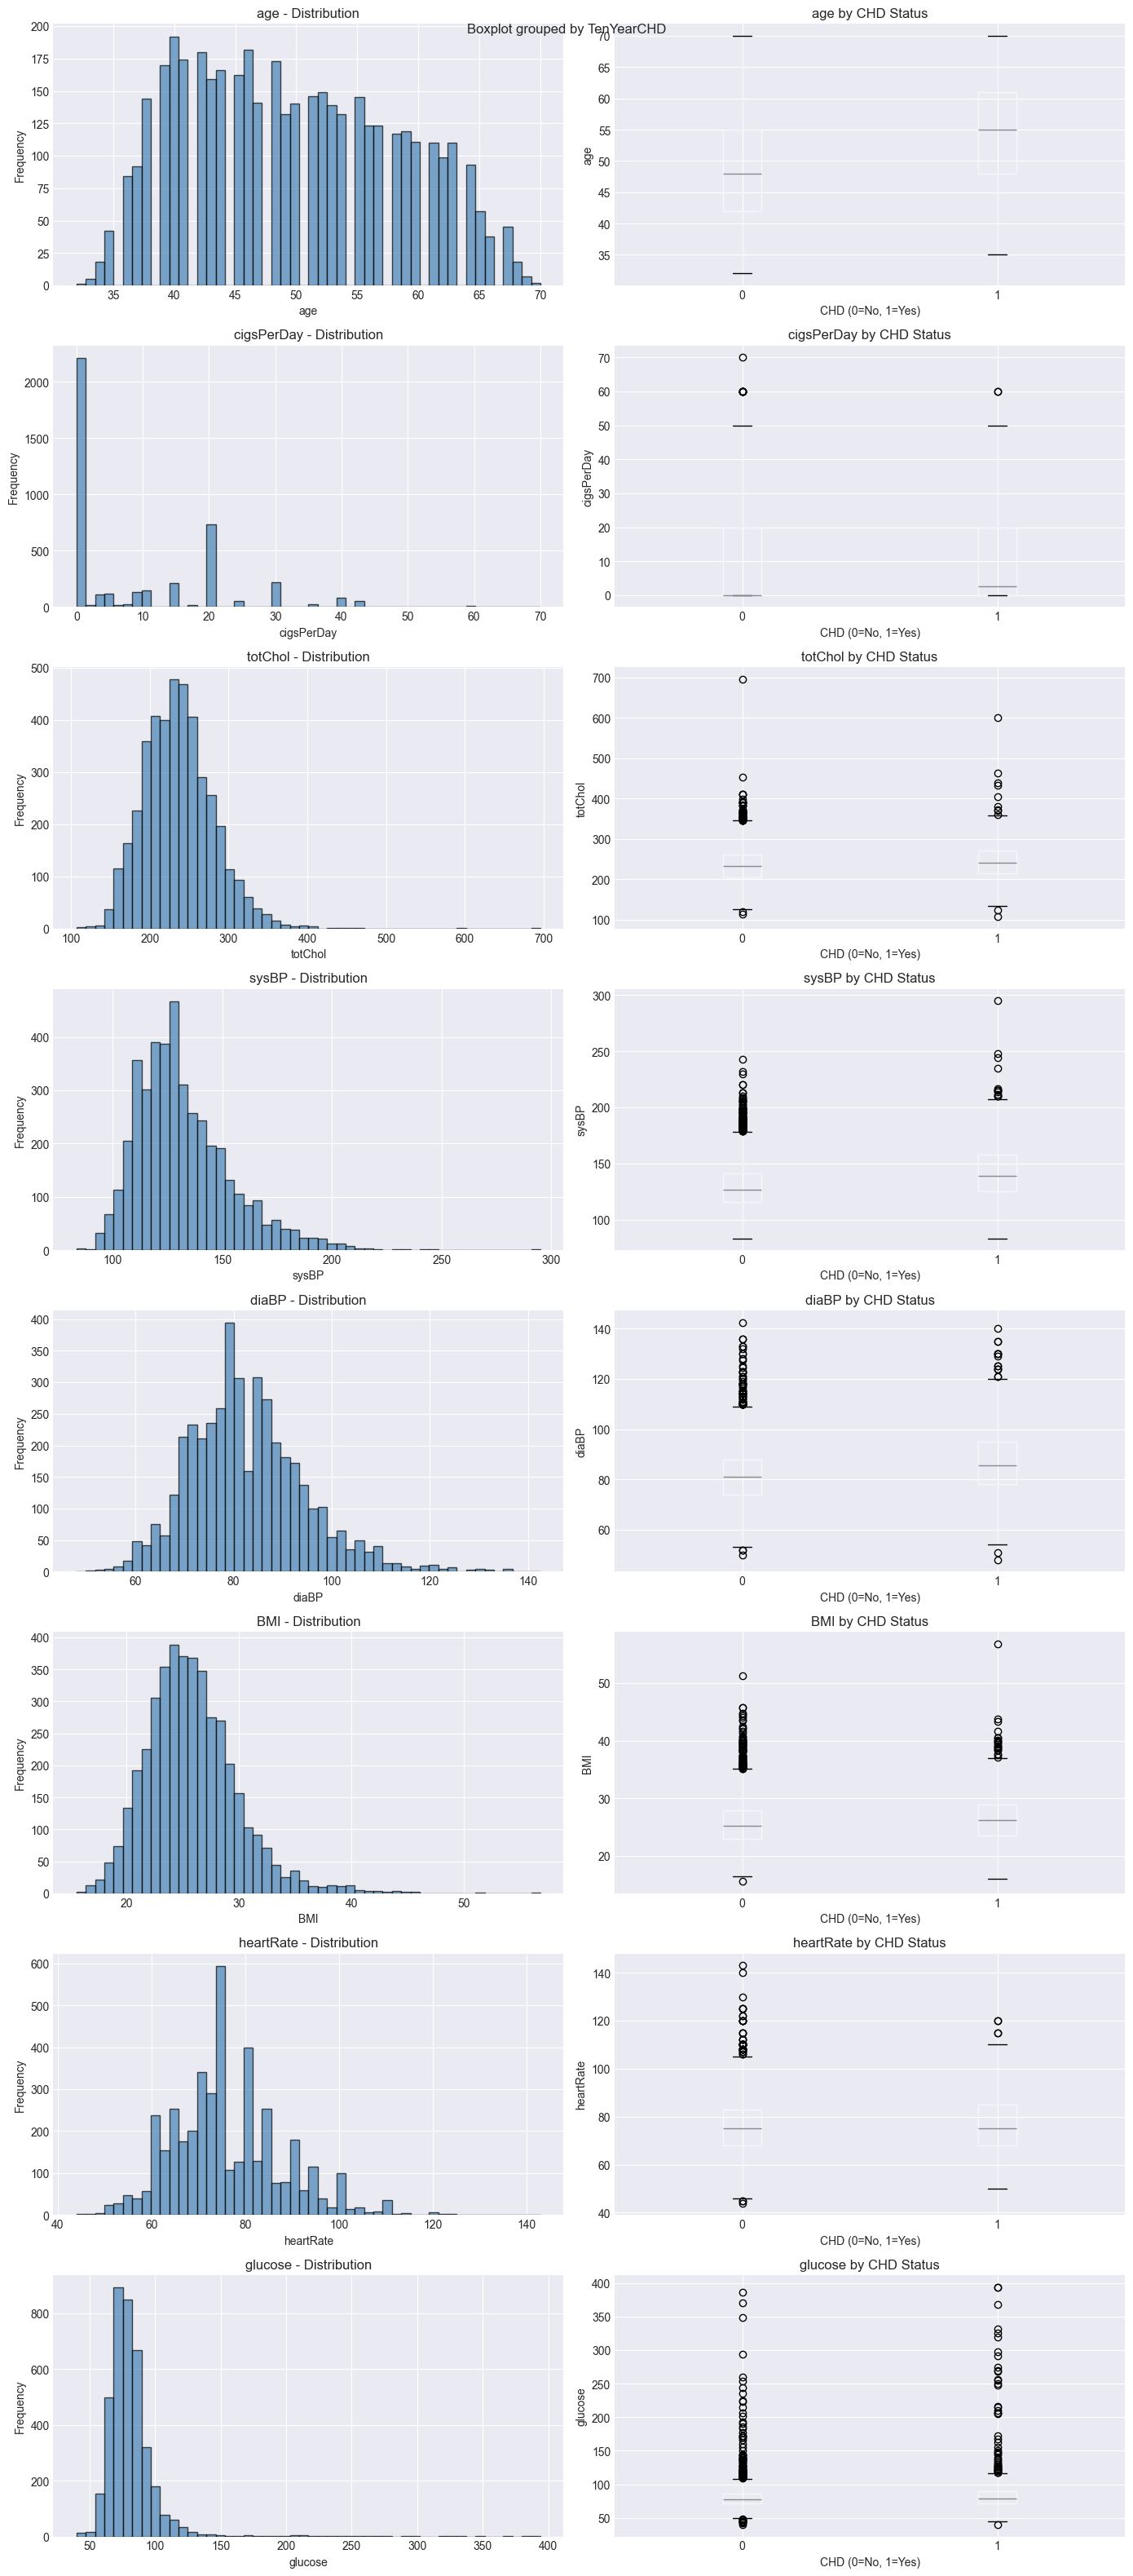

In [6]:
# Remove target from feature lists for analysis
if 'TenYearCHD' in binary_features:
    binary_features.remove('TenYearCHD')

# Visualize continuous feature distributions
fig, axes = plt.subplots(len(continuous_features), 2, figsize=(14, 4*len(continuous_features)))
axes = axes.reshape(-1, 2) if len(continuous_features) > 1 else [axes]

for idx, col in enumerate(continuous_features):
    # Histogram
    axes[idx][0].hist(df[col], bins=50, color='steelblue', edgecolor='black', alpha=0.7)
    axes[idx][0].set_title(f'{col} - Distribution')
    axes[idx][0].set_xlabel(col)
    axes[idx][0].set_ylabel('Frequency')
    
    # Box plot by target
    df.boxplot(column=col, by='TenYearCHD', ax=axes[idx][1])
    axes[idx][1].set_title(f'{col} by CHD Status')
    axes[idx][1].set_xlabel('CHD (0=No, 1=Yes)')
    axes[idx][1].set_ylabel(col)

plt.tight_layout()
plt.show()

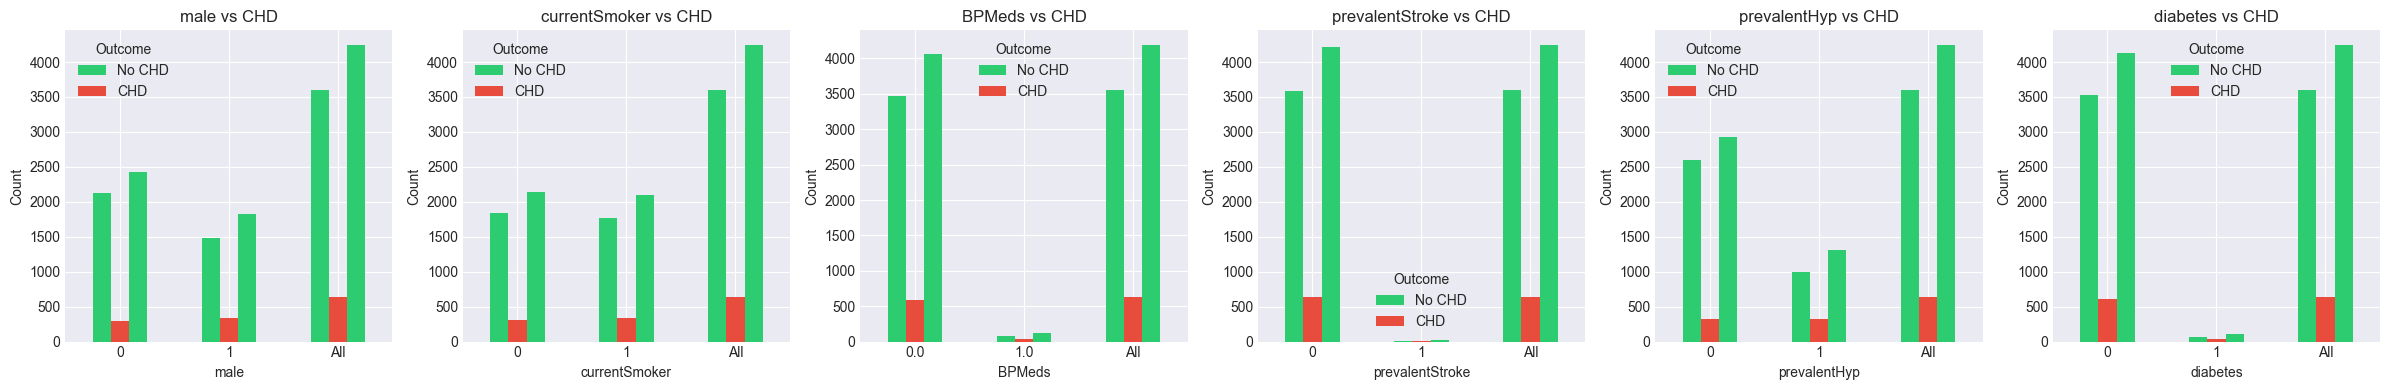

In [7]:
# Analyze binary and categorical features
fig, axes = plt.subplots(1, len(binary_features), figsize=(4*len(binary_features), 4))
axes = axes if isinstance(axes, np.ndarray) else [axes]

for idx, col in enumerate(binary_features):
    crosstab = pd.crosstab(df[col], df['TenYearCHD'], margins=True)
    crosstab.plot(kind='bar', ax=axes[idx], color=['#2ecc71', '#e74c3c'])
    axes[idx].set_title(f'{col} vs CHD')
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel('Count')
    axes[idx].legend(['No CHD', 'CHD'], title='Outcome')
    axes[idx].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

## 5. Correlation Analysis

Correlation with TenYearCHD:
TenYearCHD         1.000000
age                0.225408
sysBP              0.216374
prevalentHyp       0.177458
diaBP              0.145112
glucose            0.125590
diabetes           0.097344
male               0.088374
BPMeds             0.087519
totChol            0.082369
BMI                0.075300
prevalentStroke    0.061823
cigsPerDay         0.057755
heartRate          0.022907
currentSmoker      0.019448
education         -0.054248
Name: TenYearCHD, dtype: float64


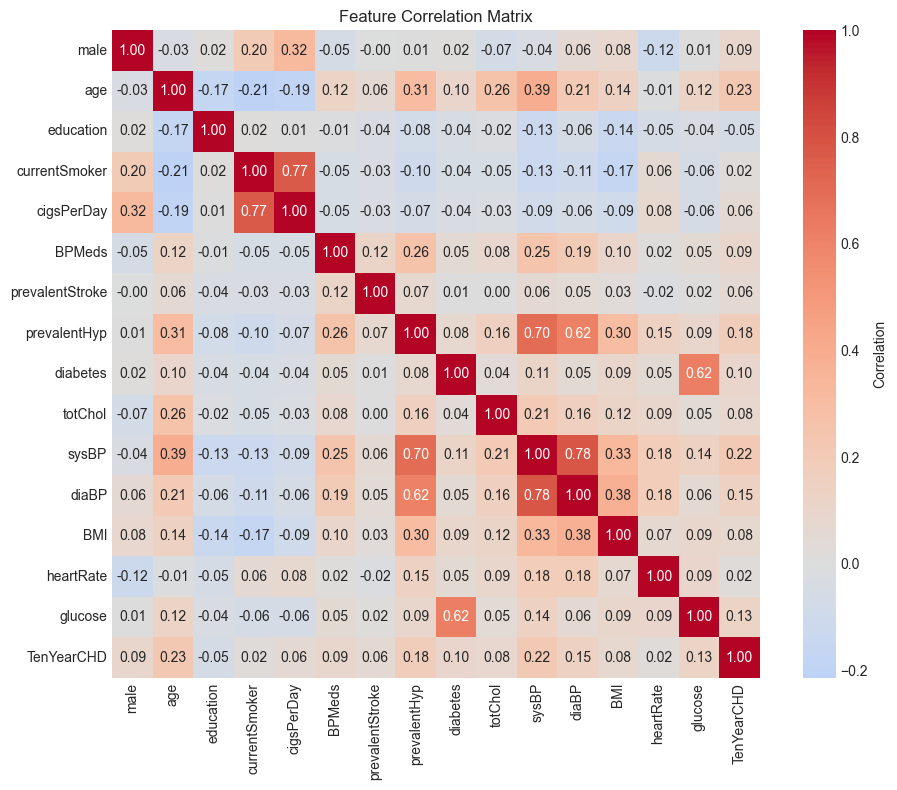

In [8]:
# Correlation with target
correlations = df.corr()['TenYearCHD'].sort_values(ascending=False)

print('Correlation with TenYearCHD:')
print(correlations)

# Visualize correlations
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax, 
            cbar_kws={'label': 'Correlation'}, square=True)
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

## 6. Feature Ranges & Scaling Needs

In [9]:
# Check feature ranges
feature_ranges = pd.DataFrame({
    'Feature': df.columns,
    'Min': df.min().values,
    'Max': df.max().values,
    'Mean': df.mean().values,
    'Std': df.std().values
})

print('Feature Ranges & Statistics:')
print(feature_ranges.to_string())

print('Note: Features have different scales so normalization is needed')

Feature Ranges & Statistics:
            Feature     Min    Max        Mean        Std
0              male    0.00    1.0    0.429245   0.495027
1               age   32.00   70.0   49.580189   8.572942
2         education    1.00    4.0    1.979444   1.019791
3     currentSmoker    0.00    1.0    0.494104   0.500024
4        cigsPerDay    0.00   70.0    9.005937  11.922462
5            BPMeds    0.00    1.0    0.029615   0.169544
6   prevalentStroke    0.00    1.0    0.005896   0.076569
7      prevalentHyp    0.00    1.0    0.310613   0.462799
8          diabetes    0.00    1.0    0.025708   0.158280
9           totChol  107.00  696.0  236.699523  44.591284
10            sysBP   83.50  295.0  132.354599  22.033300
11            diaBP   48.00  142.5   82.897759  11.910394
12              BMI   15.54   56.8   25.800801   4.079840
13        heartRate   44.00  143.0   75.878981  12.025348
14          glucose   40.00  394.0   81.963655  23.954335
15       TenYearCHD    0.00    1.0    0.151

## 7. Data Quality

### Data quality findings

- Dataset size: 4,240 records, 16 features
- Missing values in 7 columns (645 cells total): glucose (388, 9.15%), education (105, 2.48%), BPMeds (53, 1.25%), totChol (50, 1.18%), cigsPerDay (29, 0.68%), BMI (19, 0.45%), heartRate (1, 0.02%) — median imputation needed
- Class imbalance: 84.8% vs 15.2% (use of stratified splits is necessary)
- Feature scaling: Values range from 0 to 696 (excluding `education`)

### Actions to take

1. Impute missing values (median, fit on the training split only)
2. Normalize continuous features 
3. Encode categorical features (`education`)
4. Create train/test split with stratification to tackle class imbalance
5. Train models